🔍 STEP 1: INITIALIZE MODEL & DATASET
✅ Loaded XGBoost model from: xgb_fantasy_model_v1.joblib
✅ Loaded matrix X_test: 900 rows, 17 features

🧮 STEP 2: SHAP VALUE COMPUTATION
✅ SHAP values computed successfully.

📊 STEP 3: GLOBAL FEATURE IMPORTANCE (DENSITY MAP)
Visualizing directional feature impact on fantasy point generation...


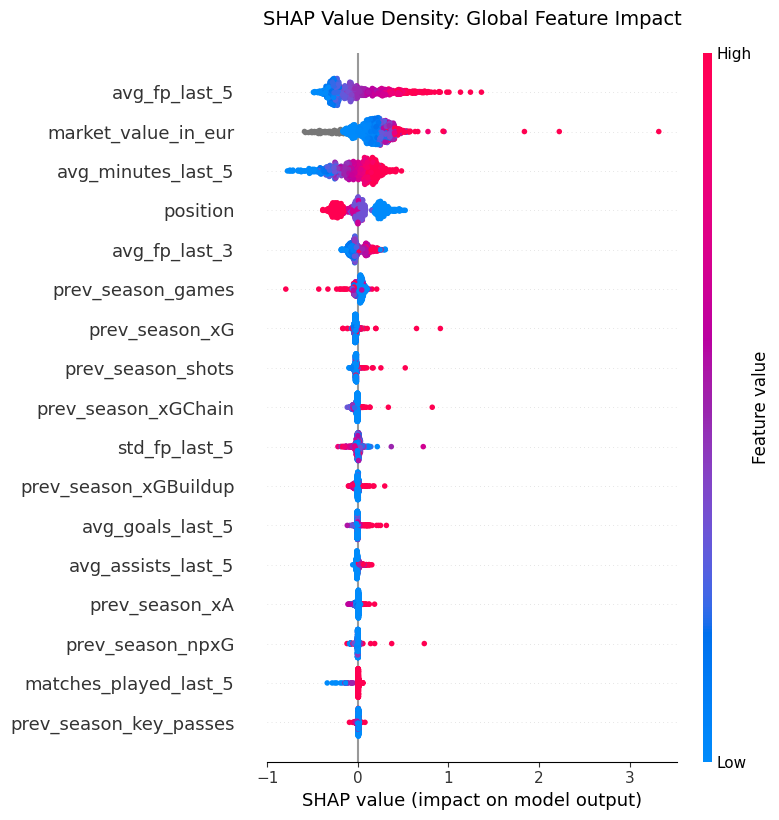


📈 STEP 4: AGGREGATE BAR IMPORTANCE PLOT
Generating macro-level report-ready feature hierarchy...


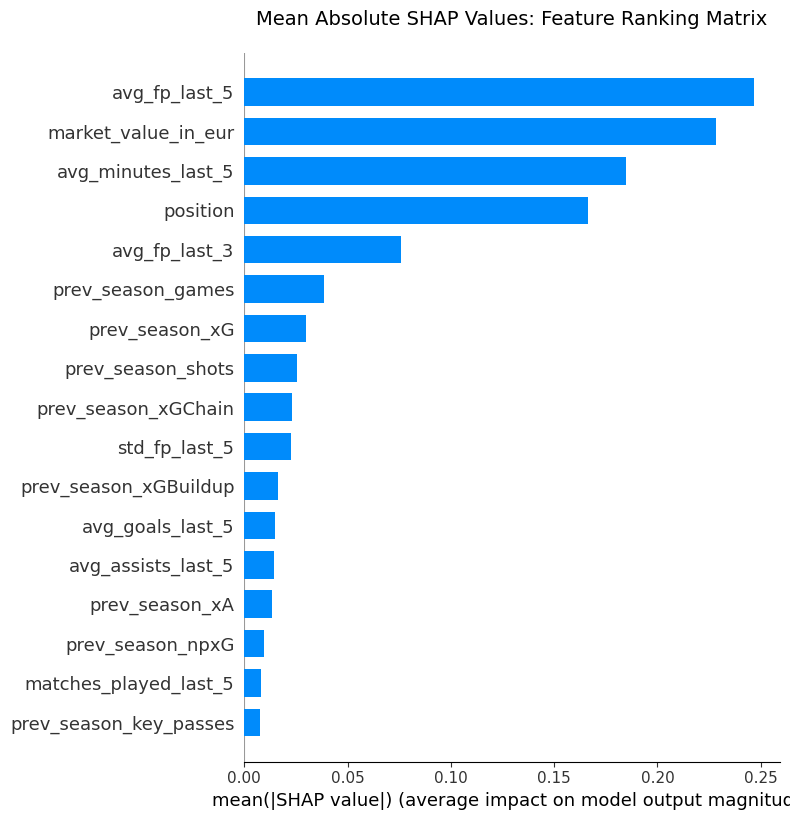

In [4]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

print("=" * 60)
print("🔍 STEP 1: INITIALIZE MODEL & DATASET")
print("=" * 60)

# Define precise relative paths
model_path = Path("../models/xgb_fantasy_model_v1.joblib")
data_path = Path("../data/processed/world_cup_inference_dataset.csv")

# Enforce strict 17-feature array ordering per schema constraints
feature_cols = [
    'market_value_in_eur', 'position', 'avg_fp_last_3', 'avg_fp_last_5',
    'avg_goals_last_5', 'avg_assists_last_5', 'avg_minutes_last_5',
    'std_fp_last_5', 'matches_played_last_5', 'prev_season_games',
    'prev_season_xG', 'prev_season_xA', 'prev_season_shots',
    'prev_season_key_passes', 'prev_season_npxG', 'prev_season_xGChain',
    'prev_season_xGBuildup'
]

# Load artifacts
model = joblib.load(model_path)
df = pd.read_csv(data_path)

# Isolate feature matrix & dynamically handle categorical position constraint
X_test = df[feature_cols].copy()
if X_test['position'].dtype == 'object':
    X_test['position'] = X_test['position'].astype('category')

print(f"✅ Loaded XGBoost model from: {model_path.name}")
print(f"✅ Loaded matrix X_test: {X_test.shape[0]} rows, {X_test.shape[1]} features")

print("\n" + "=" * 60)
print("🧮 STEP 2: SHAP VALUE COMPUTATION")
print("=" * 60)

# Compute Shapley Additive Explanations via TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values computed successfully.")

print("\n" + "=" * 60)
print("📊 STEP 3: GLOBAL FEATURE IMPORTANCE (DENSITY MAP)")
print("=" * 60)
print("Visualizing directional feature impact on fantasy point generation...")

# Generate and render summary density plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Value Density: Global Feature Impact", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("📈 STEP 4: AGGREGATE BAR IMPORTANCE PLOT")
print("=" * 60)
print("Generating macro-level report-ready feature hierarchy...")

# Generate and render magnitude bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Mean Absolute SHAP Values: Feature Ranking Matrix", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

🔍 INITIALIZING DATA ARTIFACTS FOR EXPLAINABILITY
✅ Context parsed. Aligning predictions for specific case studies...

🎯 STEP 6: EXPLAIN ONE RECOMMENDED PLAYER (WATERFALL)
Generating local attribution waterfall for Top Projected Player: Kylian MBAPPE


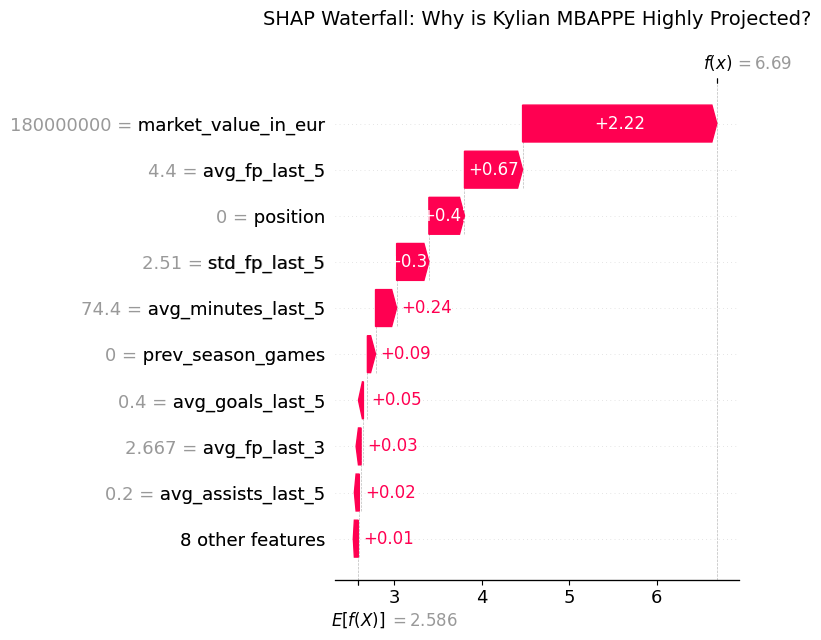


💎 STEP 7: EXPLAIN HIDDEN GEM PREDICTION
💎 TOP HIDDEN GEM CASE STUDY: Ben WAINE
• Predicted Points (Group Avg): 4.86
• Market Value: €50,000.0
• Percentile Gap (Points vs Value): +92.4%

🤖 Underlying Mathematical Attribution (Top driving features for this selection):
  - position: Feature Value = 0 (Contributed +0.49 to base projection)
  - avg_fp_last_5: Feature Value = 4.8 (Contributed +0.47 to base projection)
  - avg_minutes_last_5: Feature Value = 89.8 (Contributed +0.31 to base projection)

🛡️ STEP 8: EXPLAIN SAFE CAPTAIN PREDICTION
🛡️ TOP SAFE CAPTAIN CASE STUDY: Darwin NUNEZ
• Match-Adjusted Projection: 5.2
• Historical Volatility (std_fp_last_5): 0.0
• Safe Index Score: 5.15

🤖 Variance-Mitigation Feature Profile Check:
  - Stable Core Form: avg_fp_last_5 = 1.0
  - Minutes Floor Assurance: avg_minutes_last_5 = 22.4
  - Understat Baseline Quality: prev_season_xG = 19.187851031310856

📊 STEP 9: EXPLAIN TOURNAMENT ADJUSTMENT MECHANISM
Demonstrating context engine attenuation vs e

In [6]:
print("=" * 60)
print("🔍 INITIALIZING DATA ARTIFACTS FOR EXPLAINABILITY")
print("=" * 60)

# Define precise paths
model_path = Path("../models/xgb_fantasy_model_v1.joblib")
inference_path = Path("../data/processed/world_cup_inference_dataset.csv")
adjusted_predictions_path = Path("../data/processed/world_cup_predictions_adjusted.csv")

# Load model, inference dataset, and final analytical output
model = joblib.load(model_path)
df_inference = pd.read_csv(inference_path)
df_adjusted = pd.read_csv(adjusted_predictions_path)

# Enforce strict 17-feature array ordering per schema constraints
feature_cols = [
    'market_value_in_eur', 'position', 'avg_fp_last_3', 'avg_fp_last_5',
    'avg_goals_last_5', 'avg_assists_last_5', 'avg_minutes_last_5',
    'std_fp_last_5', 'matches_played_last_5', 'prev_season_games',
    'prev_season_xG', 'prev_season_xA', 'prev_season_shots',
    'prev_season_key_passes', 'prev_season_npxG', 'prev_season_xGChain',
    'prev_season_xGBuildup'
]

# Extract feature matrix and handle categorical constraints
X_test = df_inference[feature_cols].copy()
if X_test['position'].dtype == 'object':
    X_test['position'] = X_test['position'].astype('category')

# Initialize Explainer using the new SHAP API to generate an Explanation object
explainer = shap.TreeExplainer(model)
shap_values_obj = explainer(X_test)

print(f"✅ Context parsed. Aligning predictions for specific case studies...")

print("\n" + "=" * 60)
print("🎯 STEP 6: EXPLAIN ONE RECOMMENDED PLAYER (WATERFALL)")
print("=" * 60)

# Identify top projected player from final adjusted list
top_player_name = df_adjusted.sort_values(by='adjusted_projection', ascending=False).iloc[0]['name']
player_idx = df_inference[df_inference['name'] == top_player_name].index[0]

print(f"Generating local attribution waterfall for Top Projected Player: {top_player_name}")

# Plot individual waterfall
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values_obj[player_idx], show=False)
plt.title(f"SHAP Waterfall: Why is {top_player_name} Highly Projected?", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("💎 STEP 7: EXPLAIN HIDDEN GEM PREDICTION")
print("=" * 60)

# Re-calculate hidden gems dynamically to fetch the top candidate
df_adjusted['pred_pct_adj'] = df_adjusted['adjusted_projection'].rank(pct=True) * 100
df_adjusted['val_pct'] = df_adjusted['market_value_in_eur'].rank(pct=True) * 100
df_adjusted['gem_score_adj'] = df_adjusted['pred_pct_adj'] - df_adjusted['val_pct']

top_gem = df_adjusted[df_adjusted['pred_pct_adj'] >= 60].sort_values(by='gem_score_adj', ascending=False).iloc[0]
gem_idx = df_inference[df_inference['name'] == top_gem['name']].index[0]

print(f"💎 TOP HIDDEN GEM CASE STUDY: {top_gem['name']}")
print(f"• Predicted Points (Group Avg): {top_gem['adjusted_projection']}")
print(f"• Market Value: €{top_gem['market_value_in_eur']:,}")
print(f"• Percentile Gap (Points vs Value): +{top_gem['gem_score_adj']:.1f}%")
print("\n🤖 Underlying Mathematical Attribution (Top driving features for this selection):")

# Programmatically extract top 3 positive feature attributions for this instance
gem_shap = pd.Series(shap_values_obj.values[gem_idx], index=feature_cols)
top_drivers = gem_shap.sort_values(ascending=False).head(3)
for feat, val in top_drivers.items():
    actual_val = X_test.loc[gem_idx, feat]
    print(f"  - {feat}: Feature Value = {actual_val} (Contributed +{val:.2f} to base projection)")

print("\n" + "=" * 60)
print("🛡️ STEP 8: EXPLAIN SAFE CAPTAIN PREDICTION")
print("=" * 60)

# Identify top safe captain
df_adjusted['safe_score_adj'] = df_adjusted['adjusted_projection'] / (1 + df_adjusted['std_fp_last_5'] + 0.01)
top_safe = df_adjusted.sort_values(by='safe_score_adj', ascending=False).iloc[0]
safe_idx = df_inference[df_inference['name'] == top_safe['name']].index[0]

print(f"🛡️ TOP SAFE CAPTAIN CASE STUDY: {top_safe['name']}")
print(f"• Match-Adjusted Projection: {top_safe['adjusted_projection']}")
print(f"• Historical Volatility (std_fp_last_5): {top_safe['std_fp_last_5']}")
print(f"• Safe Index Score: {top_safe['safe_score_adj']:.2f}")
print("\n🤖 Variance-Mitigation Feature Profile Check:")

# Validate feature consistency profile
print(f"  - Stable Core Form: avg_fp_last_5 = {X_test.loc[safe_idx, 'avg_fp_last_5']}")
print(f"  - Minutes Floor Assurance: avg_minutes_last_5 = {X_test.loc[safe_idx, 'avg_minutes_last_5']}")
print(f"  - Understat Baseline Quality: prev_season_xG = {X_test.loc[safe_idx, 'prev_season_xG']}")

print("\n" + "=" * 60)
print("📊 STEP 9: EXPLAIN TOURNAMENT ADJUSTMENT MECHANISM")
print("=" * 60)
print("Demonstrating context engine attenuation vs enhancement effects:\n")

# Isolate top player and bottom/penalized player from the adjusted frame for comparison
high_mod = df_adjusted.sort_values(by='avg_fixture_multiplier', ascending=False).iloc[0]
low_mod = df_adjusted.sort_values(by='avg_fixture_multiplier', ascending=True).iloc[0]

adjustment_summary = pd.DataFrame([
    {
        'Player': high_mod['name'],
        'Base Projection': high_mod['base_projection'],
        'Adjusted Projection': high_mod['adjusted_projection'],
        'Avg Multiplier': high_mod['avg_fixture_multiplier'],
        'Context Effect': 'Favorable Group / High Win Prob'
    },
    {
        'Player': low_mod['name'],
        'Base Projection': low_mod['base_projection'],
        'Adjusted Projection': low_mod['adjusted_projection'],
        'Avg Multiplier': low_mod['avg_fixture_multiplier'],
        'Context Effect': 'Difficult Group / Low Win Prob'
    }
])

print(adjustment_summary.to_string(index=False))

